In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import skimage
import copy

import scipy
from scipy.stats import linregress, spearmanr
#import seaborn as sns
from matplotlib.markers import MarkerStyle
import matplotlib as mpl
import scanpy as sc
import BigSur
from BigSur.feature_selection import mcfano_feature_selection as mcfano
from BigSur.correlations import calculate_correlations

mpl.rcParams['pdf.fonttype'] = 42
#from watermark import watermark
#print(watermark())
#print(watermark(packages="pandas,numpy,matplotlib,skimage,scipy,seaborn,scanpy,BigSur"))

In [2]:
new_smFISH_cnts = pd.read_csv("smFISH_gene_by_cell_cnts.csv")
new_smFISH_cnts.set_index("cell id", inplace=True)

In [3]:
text_chosen_stringency_counts = pd.read_csv("cell_x_gene_mats/lf_ 3.0_dr_1_cnts.csv")
text_chosen_stringency_counts.set_index(["pos", "cellid"], inplace=True)

In [4]:
import scanpy as sc
import anndata as ad

In [5]:
def generate_corr_heatmap(text_chosen_stringency_counts, cmap="PRGn", vcenter=0, verbose=False):
    """
    Aggregated function to generate per-cell gene correlation heatmap from count data.
    
    Parameters
    ----------
    text_chosen_stringency_counts : pd.DataFrame
        Gene count matrix with shape (cells, genes). Can have multi-index with 
        (pos, cellid) as rows and genes as columns.
    cmap : str, optional
        Colormap for heatmap (default: "PRGn")
    vcenter : float, optional
        Value at which to center the colormap (default: 0)
    verbose : bool, optional
        Whether to print progress information (default: False)
    
    Returns
    -------
    tuple
        (adata_sorted_cor, fig) - AnnData object with correlations and leiden clustering,
        and the resulting heatmap figure
    """
    import numpy as np
    import pandas as pd
    import scipy
    import anndata as ad
    import scanpy as sc
    from BigSur.correlations import calculate_correlations
    
    # Create a working copy with index reset to avoid multi-index complications
    counts_data = text_chosen_stringency_counts.reset_index(drop=True).copy()
    # Fill any NaN values and ensure data is integer type (raw counts required by calculate_correlations)
    counts_data = counts_data.fillna(0)
    counts_data = counts_data.astype('int')
    
    # Step 1: Create initial AnnData with cells as observations and genes as variables
    # Use DataFrame directly to preserve dtypes better
    adata = ad.AnnData(X=counts_data)
    # Overwrite with integer sparse matrix
    adata.X = scipy.sparse.csc_matrix(counts_data.values.astype('int'))
    adata.layers['counts'] = scipy.sparse.csc_matrix(adata.X)
    if verbose:
        print(f"Step 1: Created AnnData object with shape {adata.shape}")
    
    # Step 2: Calculate gene-gene correlations
    calculate_correlations(adata, layer='counts', cv=None, verbose=verbose, 
                          previously_run=False, store_intermediate_results=True)
    if verbose:
        print("Step 2: Calculated gene-gene correlations")
    
    # Step 3: Get correlation matrix and create correlation AnnData (genes x genes)
    corrs = adata.varm['mcPCCs'].toarray()
    corrs += np.transpose(corrs)  # Symmetrize the correlation matrix
    adata_cor = ad.AnnData(corrs)
    adata_cor.var = adata.var.copy()
    adata_cor.obs = adata.var.copy()
    if verbose:
        print(f"Step 3: Created correlation AnnData with shape {adata_cor.shape}")
    
    # Step 4: Compute neighbors and leiden clustering on correlation space (genes)
    sc.pp.neighbors(adata_cor, use_rep='X')
    sc.tl.leiden(adata_cor)
    if verbose:
        print("Step 4: Computed neighbors and leiden clustering on genes")
    
    # Step 5: Sort genes by leiden cluster
    leiden_indices = adata_cor.obs.reset_index().set_index(['leiden', 'index']).index
    
    # Work with the clean copy for transposition
    counts_data_tp = counts_data.T  # Transpose using .T to preserve DataFrame
    counts_data_tp.index = leiden_indices
    counts_data_tp.sort_index(axis=0, inplace=True)
    leiden_sorted = counts_data_tp.T  # Transpose back
    if verbose:
        print(f"Step 5: Sorted genes by leiden cluster")
    
    # Step 6: Create sorted AnnData and calculate correlations again on sorted data
    adata_sorted = ad.AnnData(np.array(leiden_sorted))
    adata_sorted.layers['counts'] = scipy.sparse.csc_matrix(adata_sorted.X)
    
    calculate_correlations(adata_sorted, layer='counts', cv=None, verbose=verbose,
                          previously_run=False, store_intermediate_results=True)
    if verbose:
        print("Step 6: Recalculated correlations on sorted genes")
    
    # Step 7: Create final sorted correlation AnnData
    adata_sorted_cor = ad.AnnData(
        adata_sorted.varm['mcPCCs'].toarray() + 
        np.transpose(adata_sorted.varm['mcPCCs'].toarray())
    )
    adata_sorted_cor.obs.index = counts_data_tp.index
    adata_sorted_cor.obs.reset_index(inplace=True)
    adata_sorted_cor.var = adata_sorted.var.copy()
    if verbose:
        print(f"Step 7: Final sorted correlation AnnData with shape {adata_sorted_cor.shape}")
    
    # Step 8: Generate heatmap with square dimensions
    fig = sc.pl.heatmap(adata_sorted_cor, groupby='leiden', 
                        var_names=adata_sorted_cor.var.index, 
                        cmap=cmap, vcenter=vcenter, figsize=(12, 12))
    
    return adata_sorted_cor, fig

c:\Users\jonat\miniconda3\envs\bigsur_env2\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Step 1: Created AnnData object with shape (217, 271)
After fitting, cv = 0.15
Estimating p-values.
Step 2: Calculated gene-gene correlations
Step 3: Created correlation AnnData with shape (271, 271)


c:\Users\jonat\miniconda3\envs\bigsur_env2\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\jonat\AppData\Local\Temp\ipykernel_4168\945014682.py:62: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’

Step 4: Computed neighbors and leiden clustering on genes
Step 5: Sorted genes by leiden cluster
After fitting, cv = 0.15
Estimating p-values.
Step 6: Recalculated correlations on sorted genes
Step 7: Final sorted correlation AnnData with shape (271, 271)


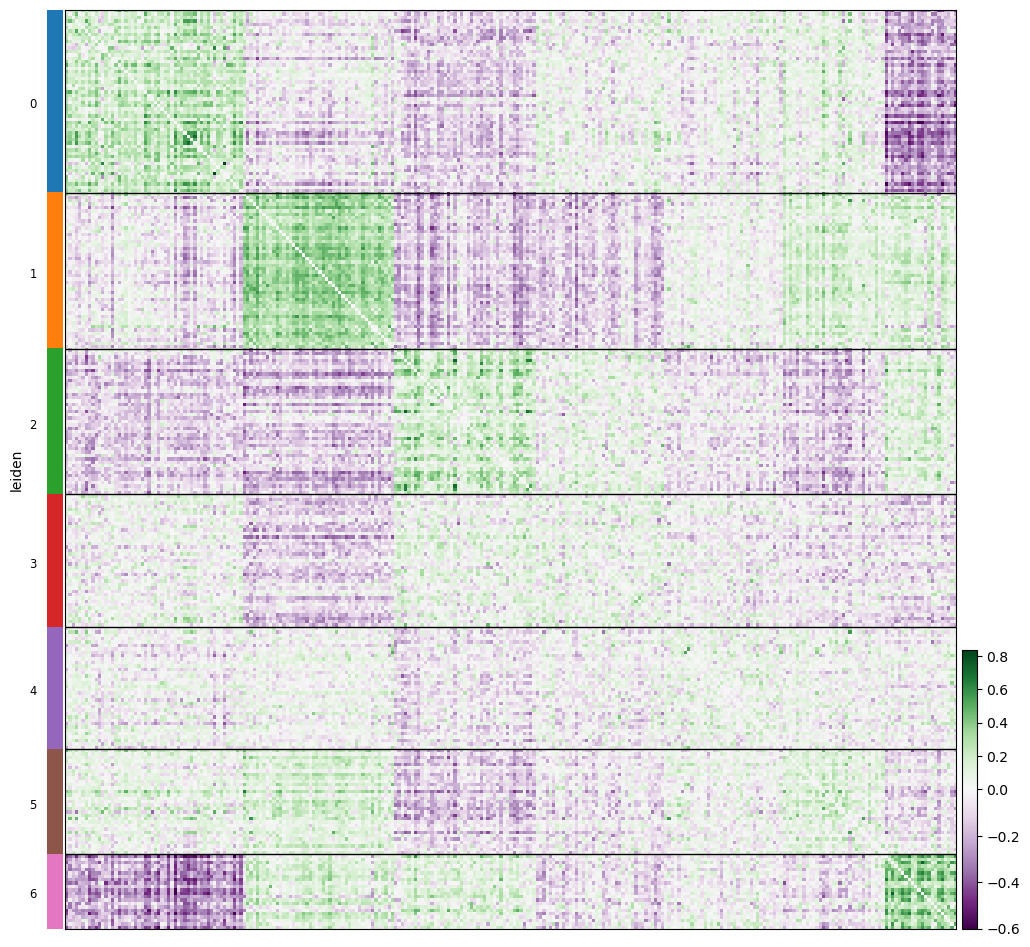

In [6]:
adata_sorted_cor_test, fig_test = generate_corr_heatmap(
    text_chosen_stringency_counts, 
    cmap="PRGn", 
    vcenter=0,
    verbose=True
)

c:\Users\jonat\miniconda3\envs\bigsur_env2\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\jonat\miniconda3\envs\bigsur_env2\Lib\site-packages\BigSur\preprocessing.py:94: UserWarning: CV cannot be fit in biological range -- this probably means that the dataset is composed of multiple celltypes. We recommend subsetting the celltypes and redoing CV fit. Setting CV = 0.5.
  warnings.warn(


Step 1: Created AnnData object with shape (218, 49)
After fitting, cv = 0.5
Estimating p-values.
Step 2: Calculated gene-gene correlations
Step 3: Created correlation AnnData with shape (49, 49)
Step 4: Computed neighbors and leiden clustering on genes
Step 5: Sorted genes by leiden cluster
After fitting, cv = 0.5


C:\Users\jonat\AppData\Local\Temp\ipykernel_4168\945014682.py:62: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_cor)
c:\Users\jonat\miniconda3\envs\bigsur_env2\Lib\site-packages\BigSur\preprocessing.py:94: UserWarning: CV cannot be fit in biological range -- this probably means that the dataset is composed of multiple celltypes. We recommend subsetting the celltypes and redoing CV fit. Setting CV = 0.5.
  warnings.warn(


Estimating p-values.
Step 6: Recalculated correlations on sorted genes
Step 7: Final sorted correlation AnnData with shape (49, 49)


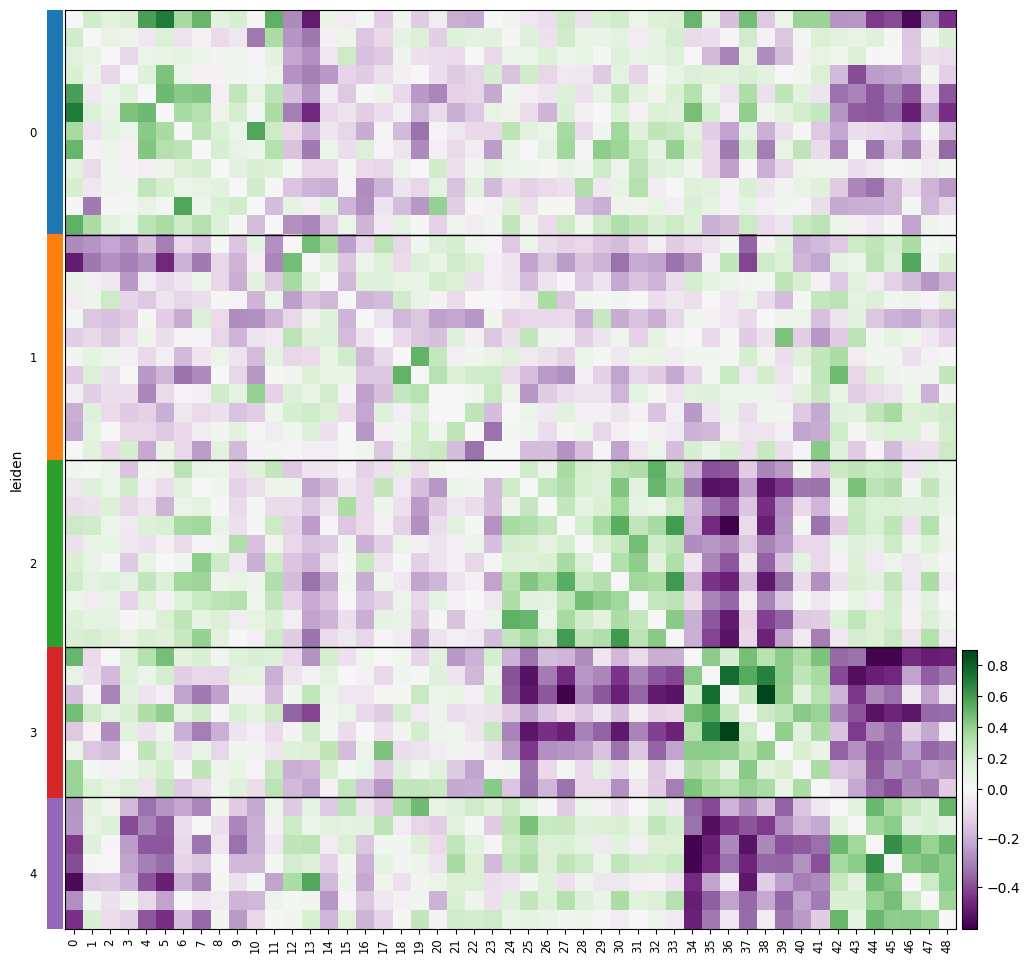

In [7]:
new_smFISH_cnts
adata_sorted_cor_smFISH, fig_smFISH = generate_corr_heatmap(
    new_smFISH_cnts, 
    cmap="PRGn", 
    vcenter=0,
    verbose=True
)

In [8]:
adata_sorted_cor_test.obs.set_index("index", inplace=True)


In [9]:
adata_sorted_cor_test.obs["Leiden clusters"] = adata_sorted_cor_test.obs['leiden']

C:\Users\jonat\AppData\Local\Temp\ipykernel_4168\3812013094.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.heatmap(adata_sorted_cor_test, groupby='Leiden clusters',


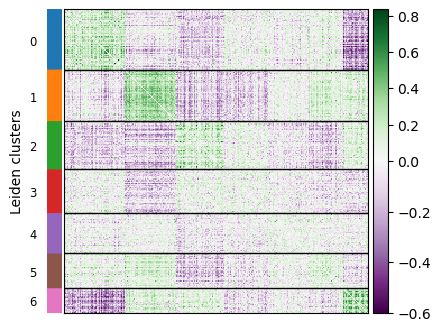

In [10]:
sc.pl.heatmap(adata_sorted_cor_test, groupby='Leiden clusters', 
                        var_names=adata_sorted_cor_test.var.index, 
                        cmap="PRGn", vcenter=0, figsize=(4.4, 4),save="full_seqFISH_per_cell_gene_gene_cor_mat.pdf")

In [11]:
adata_sorted_cor_smFISH.obs.set_index('index', inplace=True)

In [12]:
adata_sorted_cor_smFISH.var.index = adata_sorted_cor_smFISH.obs.index

In [13]:
import copy

In [14]:
sf_lc = copy.deepcopy(adata_sorted_cor_test.obs)

In [15]:
sf_lc["smFISH_leiden"] = adata_sorted_cor_smFISH.obs['leiden']

In [16]:
sf_lc.dropna(inplace=True)

In [17]:
sf_lc.sort_values(by=['smFISH_leiden', 'leiden'], inplace=True)

In [18]:
sf_lc.sort_values(by=['leiden', 'smFISH_leiden'], inplace=True)

In [19]:
adata_sorted_cor_test.var.index = adata_sorted_cor_test.obs.index

In [20]:
adata_sorted_cor_overlap = adata_sorted_cor_test[sf_lc.index, sf_lc.index]
adata_sorted_cor_overlap.obs["Full seqFISH panel Leiden clusters"] = sf_lc['leiden']

C:\Users\jonat\AppData\Local\Temp\ipykernel_4168\3401122944.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sorted_cor_overlap.obs["Full seqFISH panel Leiden clusters"] = sf_lc['leiden']


In [21]:
adata_sorted_cor_smFISH_overlap = adata_sorted_cor_smFISH[sf_lc.index, sf_lc.index]

In [22]:
adata_sorted_cor_smFISH_overlap.obs["seqFISH_leiden"] = sf_lc['leiden']
adata_sorted_cor_smFISH_overlap.obs["Full seqFISH panel Leiden clusters"] = sf_lc['leiden']

C:\Users\jonat\AppData\Local\Temp\ipykernel_4168\2398597552.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sorted_cor_smFISH_overlap.obs["seqFISH_leiden"] = sf_lc['leiden']


C:\Users\jonat\AppData\Local\Temp\ipykernel_4168\1537570088.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.heatmap(adata_sorted_cor_overlap, groupby="Full seqFISH panel Leiden clusters",


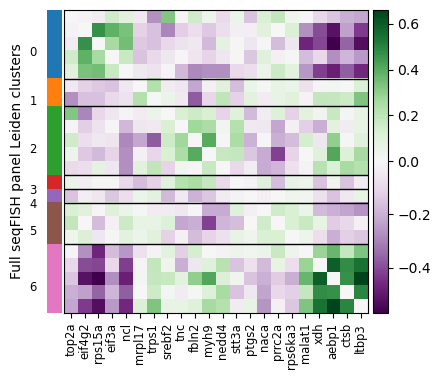

In [23]:
sc.pl.heatmap(adata_sorted_cor_overlap, groupby="Full seqFISH panel Leiden clusters",
                        var_names=sf_lc.index, 
                        cmap="PRGn", vcenter=0, figsize=(4.4, 4), save="seqFISH_overlap.pdf")

C:\Users\jonat\AppData\Local\Temp\ipykernel_4168\1087989225.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.heatmap(adata_sorted_cor_smFISH_overlap, groupby="Full seqFISH panel Leiden clusters",


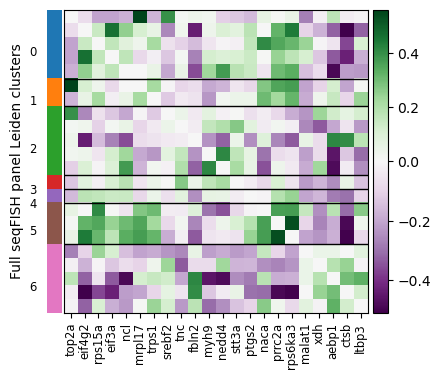

In [24]:
sc.pl.heatmap(adata_sorted_cor_smFISH_overlap, groupby="Full seqFISH panel Leiden clusters",
                        var_names=sf_lc.index, 
                        cmap="PRGn", vcenter=0, figsize=(4.4, 4), save="smFISH_overlap.pdf")


# 